# V1 Mask Pixel Count and Compression Demo

This notebook does two things:

1. Loads a longitudinal `day_pointer` file and counts how many pixels are inside `V1_mask_stim` and inside `final_mask & V1_mask_stim`.
2. Reconstructs one evoked map from the TIFF stack, then compares the original map to `2x` and `4x` spatial binning.

Edit the configuration cell below to point to your data.


In [7]:
# If your notebook kernel is missing packages, uncomment and run this once:
# %pip install numpy scipy matplotlib tifffile h5py imageio

import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

try:
    import h5py
except ImportError:
    h5py = None

try:
    import tifffile
except ImportError:
    tifffile = None

try:
    import imageio.v3 as iio
except ImportError:
    iio = None


In [8]:
# -------------------------
# USER CONFIG
# -------------------------
DAY_POINTER_FILE = r"C:\Albert Li\LGN\LGN_wf_longitudinal\LGN11_longitudinal\2026-03-29\analysis\LGN11_20260328_day_pointer.mat"

# Trial selection for the visual compression comparison.
# First run the condition-summary cell to see valid channel/current combinations.
TARGET_CHANNEL = 144
TARGET_CURRENT_UA = 7
TARGET_TRIAL_INDEX_WITHIN_CONDITION = 0  # zero-based index within the selected condition

# Time windows used to reconstruct an evoked map from the TIFF stack.
BASELINE_SEC = (-1.0, 0.0)
RESPONSE_SEC = (0.0, 1.0)

# Visualization settings.
DISPLAY_PAD_PX = 10
MASK_OCCUPANCY_THRESHOLD = 0.0  # 0.0 = keep any binned cell touched by V1

day_pointer_path = Path(DAY_POINTER_FILE)
assert day_pointer_path.exists(), f"DAY_POINTER_FILE does not exist: {day_pointer_path}"


In [9]:
def _decode_hdf5_char(data):
    arr = np.asarray(data)
    arr = np.squeeze(arr)
    if arr.ndim > 1:
        arr = arr.T
    arr = np.ravel(arr)
    return ''.join(chr(int(x)) for x in arr if int(x) != 0)


def _convert_hdf5_node(node, h5file):
    if isinstance(node, h5py.Group):
        out = {}
        for key in node.keys():
            if key.startswith('#'):
                continue
            out[key] = _convert_hdf5_node(node[key], h5file)
        return out

    data = node[()]
    matlab_class = node.attrs.get('MATLAB_class', b'')
    if isinstance(matlab_class, bytes):
        matlab_class = matlab_class.decode('utf-8')

    if matlab_class == 'char':
        return _decode_hdf5_char(data)

    if h5py.check_dtype(ref=node.dtype) is not None:
        flat_refs = np.ravel(data, order='F')
        values = [_convert_hdf5_node(h5file[ref], h5file) for ref in flat_refs]
        if len(values) == 1:
            return values[0]
        return values

    arr = np.array(data)
    arr = np.squeeze(arr)

    if matlab_class == 'logical':
        arr = arr.astype(bool)

    if arr.ndim >= 2:
        arr = np.transpose(arr)

    if arr.shape == ():
        return arr.item()

    return arr


def load_mat_v73(path):
    if h5py is None:
        raise RuntimeError(
            'This file is MATLAB v7.3/HDF5, but h5py is not installed. '
            'Install it with: %pip install h5py'
        )

    with h5py.File(path, 'r') as h5file:
        out = {}
        for key in h5file.keys():
            if key.startswith('#'):
                continue
            out[key] = _convert_hdf5_node(h5file[key], h5file)
        return out


def load_mat_struct(path):
    try:
        data = loadmat(path, simplify_cells=True)
    except NotImplementedError:
        data = load_mat_v73(path)
    return {k: v for k, v in data.items() if not k.startswith('__')}


def get_day_pointer(mat_dict):
    if 'day_pointer' in mat_dict:
        return mat_dict['day_pointer']
    if 'C' in mat_dict:
        return mat_dict['C']
    raise KeyError('Expected "day_pointer" or legacy "C" in the selected MAT file.')


def resolve_existing_path(path_like, dataset_root, expect_dir=False):
    path = Path(path_like)
    candidates = [path]
    if dataset_root is not None:
        candidates.append(Path(dataset_root) / path)

    for candidate in candidates:
        if expect_dir and candidate.is_dir():
            return candidate.resolve()
        if not expect_dir and candidate.is_file():
            return candidate.resolve()

    raise FileNotFoundError(f'Could not resolve path: {path_like}')


def infer_camera_rate(day_pointer):
    meta = day_pointer['meta']
    for key in ('camera_rate_hz', 'Freq'):
        if key in meta and meta[key] is not None:
            return float(meta[key])
    raise KeyError('Could not infer camera rate from day_pointer.meta.camera_rate_hz or day_pointer.meta.Freq')


def sorted_tiff_files(img_dir):
    files = list(Path(img_dir).glob('*.tif')) + list(Path(img_dir).glob('*.tiff'))
    if not files:
        raise FileNotFoundError(f'No TIFF files found in {img_dir}')

    def trailing_number(path):
        match = re.search(r'(\d+)\.(tif|tiff)$', path.name, re.IGNORECASE)
        if match is None:
            raise ValueError(f'TIFF filename is missing a trailing numeric index: {path.name}')
        return int(match.group(1))

    return sorted(files, key=trailing_number)


def scalarize_numeric(value, field_name='value'):
    arr = np.asarray(value)
    arr = np.squeeze(arr)
    if arr.shape == ():
        return float(arr)
    flat = np.ravel(arr)
    if flat.size == 1:
        return float(flat[0])
    raise ValueError(f'Expected scalar-like numeric data for {field_name}, got shape {arr.shape}')


def unpack_day_pointer_entries(entries):
    frame_idx = []
    channels = []
    currents = []
    trial_ids = []

    if isinstance(entries, dict):
        entries = [entries]

    for entry in entries:
        onset = np.atleast_1d(np.asarray(entry['trial_onset_frame_idx'], dtype=float)).ravel()
        n_trials = onset.size
        stim_channel = scalarize_numeric(entry['stim_channel'], 'stim_channel')
        current_uA = scalarize_numeric(entry['current_uA'], 'current_uA')

        frame_idx.append(onset)
        channels.append(np.full(n_trials, stim_channel))
        currents.append(np.full(n_trials, current_uA))

        if 'trial_index' in entry and entry['trial_index'] is not None:
            trial_ids.append(np.atleast_1d(np.asarray(entry['trial_index'], dtype=float)).ravel())
        else:
            trial_ids.append(np.full(n_trials, np.nan))

    return (
        np.concatenate(frame_idx),
        np.concatenate(channels),
        np.concatenate(currents),
        np.concatenate(trial_ids),
    )


def frame_window_to_offsets(window_sec, fs):
    start_idx = int(math.ceil(window_sec[0] * fs))
    end_idx = int(math.floor(window_sec[1] * fs)) - 1
    return np.arange(start_idx, end_idx + 1, dtype=int)


def load_frame(tiff_paths, frame_idx_1based):
    frame_path = str(tiff_paths[int(frame_idx_1based) - 1])
    if tifffile is not None:
        return tifffile.imread(frame_path).astype(np.float32)
    if iio is not None:
        return iio.imread(frame_path).astype(np.float32)
    raise RuntimeError(
        'No TIFF reader is available. Install tifffile or imageio, for example: '
        '%pip install tifffile imageio'
    )


def build_evoked_map(tiff_paths, onset_frame_1based, baseline_offsets, response_offsets):
    baseline_stack = np.stack([load_frame(tiff_paths, onset_frame_1based + off) for off in baseline_offsets], axis=0)
    response_stack = np.stack([load_frame(tiff_paths, onset_frame_1based + off) for off in response_offsets], axis=0)
    baseline_mean = baseline_stack.mean(axis=0)
    response_mean = response_stack.mean(axis=0)
    return response_mean - baseline_mean


def bbox_from_mask(mask, pad=0):
    y, x = np.where(mask)
    if y.size == 0:
        raise ValueError('Mask is empty.')
    y0 = max(0, int(y.min()) - pad)
    y1 = min(mask.shape[0], int(y.max()) + pad + 1)
    x0 = max(0, int(x.min()) - pad)
    x1 = min(mask.shape[1], int(x.max()) + pad + 1)
    return y0, y1, x0, x1


def crop(arr, bbox):
    y0, y1, x0, x1 = bbox
    return arr[y0:y1, x0:x1]


def block_reduce_mean(arr, factor):
    h, w = arr.shape
    h_trim = (h // factor) * factor
    w_trim = (w // factor) * factor
    arr_trim = arr[:h_trim, :w_trim]
    return arr_trim.reshape(h_trim // factor, factor, w_trim // factor, factor).mean(axis=(1, 3))


def upsample_repeat(arr, factor):
    return np.repeat(np.repeat(arr, factor, axis=0), factor, axis=1)


def compress_map(arr, factor):
    reduced = block_reduce_mean(arr, factor)
    recon = upsample_repeat(reduced, factor)
    return reduced, recon


def mask_coverage_counts(mask, factor, threshold=0.0):
    reduced = block_reduce_mean(mask.astype(np.float32), factor)
    occupied = reduced > threshold
    return reduced, occupied, int(occupied.sum())


def masked_error_metrics(original, reconstructed, mask):
    h = min(original.shape[0], reconstructed.shape[0], mask.shape[0])
    w = min(original.shape[1], reconstructed.shape[1], mask.shape[1])
    diff = original[:h, :w] - reconstructed[:h, :w]
    valid = mask[:h, :w].astype(bool)
    vals = diff[valid]
    if vals.size == 0:
        return {'rmse': np.nan, 'mae': np.nan}
    return {
        'rmse': float(np.sqrt(np.mean(vals ** 2))),
        'mae': float(np.mean(np.abs(vals))),
    }


day_pointer: C:\Albert Li\LGN\LGN_wf_longitudinal\LGN11_longitudinal\2026-03-29\analysis\LGN11_20260328_day_pointer.mat
day_setup_file: C:\Albert Li\LGN\LGN_wf_longitudinal\LGN11_longitudinal\2026-03-29\analysis\LGN11_20260328_reference_mask_and_retino_alignment.mat
img_dir: C:\Albert Li\LGN\LGN_wf_longitudinal\LGN11_longitudinal\2026-03-29\img
camera rate: 10.000 Hz
frame count: 70939
full image size: 256 x 256
pixels in V1_mask_stim: 7282
pixels in final_mask: 35254
pixels in analysis_mask = final_mask & V1_mask_stim: 6715


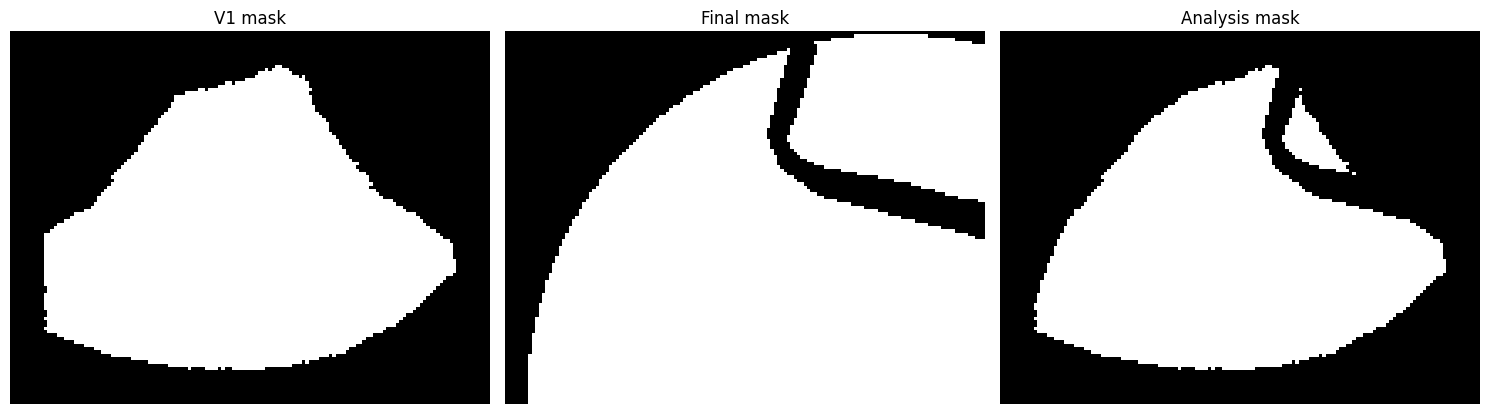

In [11]:
# -------------------------
# LOAD POINTER, DAY SETUP, AND MASKS
# -------------------------
pointer_data = load_mat_struct(day_pointer_path)
day_pointer = get_day_pointer(pointer_data)

dataset_root = day_pointer['meta']['dataset_root']
day_setup_file = resolve_existing_path(day_pointer['meta']['day_setup_file_rel'], dataset_root, expect_dir=False)
img_dir = resolve_existing_path(day_pointer['meta']['img_dir_rel'], dataset_root, expect_dir=True)

day_setup_data = load_mat_struct(day_setup_file)
if 'day_setup' not in day_setup_data:
    raise KeyError(f'day_setup was not found in {day_setup_file}')
day_setup = day_setup_data['day_setup']

final_mask = np.asarray(day_setup['reference_mask']['final_mask']).astype(bool)
V1_mask = np.asarray(day_setup['retino_align']['V1_mask_stim']).astype(bool)
analysis_mask = final_mask & V1_mask

bbox = bbox_from_mask(V1_mask, pad=DISPLAY_PAD_PX)
fs = 10
tiff_paths = sorted_tiff_files(img_dir)

print(f'day_pointer: {day_pointer_path}')
print(f'day_setup_file: {day_setup_file}')
print(f'img_dir: {img_dir}')
print(f'camera rate: {fs:.3f} Hz')
print(f'frame count: {len(tiff_paths)}')
print(f'full image size: {V1_mask.shape[0]} x {V1_mask.shape[1]}')
print(f'pixels in V1_mask_stim: {int(V1_mask.sum())}')
print(f'pixels in final_mask: {int(final_mask.sum())}')
print(f'pixels in analysis_mask = final_mask & V1_mask_stim: {int(analysis_mask.sum())}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(crop(V1_mask, bbox), cmap='gray')
axes[0].set_title('V1 mask')
axes[1].imshow(crop(final_mask, bbox), cmap='gray')
axes[1].set_title('Final mask')
axes[2].imshow(crop(analysis_mask, bbox), cmap='gray')
axes[2].set_title('Analysis mask')
for ax in axes:
    ax.axis('off')
plt.tight_layout()


In [ ]:
# -------------------------
# LIST AVAILABLE CHANNEL/CURRENT CONDITIONS
# -------------------------
entries = day_pointer['entries']
frame_idx, channels, currents, trial_ids = unpack_day_pointer_entries(entries)

baseline_offsets = frame_window_to_offsets(BASELINE_SEC, fs)
response_offsets = frame_window_to_offsets(RESPONSE_SEC, fs)
max_backward = int(abs(min(baseline_offsets.min(), response_offsets.min())))
max_forward = int(max(baseline_offsets.max(), response_offsets.max()))

valid = (
    np.isfinite(frame_idx)
    & np.isfinite(channels)
    & np.isfinite(currents)
    & (frame_idx > max_backward)
    & (frame_idx <= (len(tiff_paths) - max_forward))
)

frame_idx = frame_idx[valid].astype(int)
channels = channels[valid].astype(int)
currents = currents[valid]
trial_ids = trial_ids[valid]

summary_rows = []
for ch in np.unique(channels):
    for cur in np.unique(currents[channels == ch]):
        keep = (channels == ch) & np.isclose(currents, cur)
        summary_rows.append((int(ch), float(cur), int(keep.sum())))

summary_rows = sorted(summary_rows, key=lambda row: (row[0], row[1]))
for ch, cur, n_trials in summary_rows:
    print(f'channel={ch:>3d} | current_uA={cur:>6g} | n_trials={n_trials}')


ValueError: Expected scalar-like numeric data for stim_channel, got shape (66,)

: 

In [ ]:
# -------------------------
# SELECT ONE MAP TO COMPARE
# -------------------------
selected = (channels == TARGET_CHANNEL) & np.isclose(currents, TARGET_CURRENT_UA)
selected_frame_idx = frame_idx[selected]
selected_trial_ids = trial_ids[selected]

if selected_frame_idx.size == 0:
    raise ValueError(
        f'No trials found for TARGET_CHANNEL={TARGET_CHANNEL}, TARGET_CURRENT_UA={TARGET_CURRENT_UA}. '
        'Run the condition-summary cell above and choose a valid combination.'
    )

if TARGET_TRIAL_INDEX_WITHIN_CONDITION >= selected_frame_idx.size:
    raise IndexError(
        f'TARGET_TRIAL_INDEX_WITHIN_CONDITION={TARGET_TRIAL_INDEX_WITHIN_CONDITION} is out of range. '
        f'This condition has only {selected_frame_idx.size} trial(s).'
    )

onset_frame = int(selected_frame_idx[TARGET_TRIAL_INDEX_WITHIN_CONDITION])
selected_trial_id = selected_trial_ids[TARGET_TRIAL_INDEX_WITHIN_CONDITION]

evoked_map = build_evoked_map(
    tiff_paths=tiff_paths,
    onset_frame_1based=onset_frame,
    baseline_offsets=baseline_offsets,
    response_offsets=response_offsets,
)

display_map = evoked_map.copy()
display_map[~final_mask] = np.nan
display_crop = crop(display_map, bbox)
analysis_crop = crop(analysis_mask, bbox)

finite_vals = display_crop[np.isfinite(display_crop)]
if finite_vals.size == 0:
    raise ValueError('Selected map has no finite pixels inside the displayed crop.')

clim = np.quantile(finite_vals, [0.02, 0.98])
clim_abs = float(max(abs(clim[0]), abs(clim[1])))
clim = (-clim_abs, clim_abs)

print(f'selected onset frame: {onset_frame}')
print(f'selected trial id: {selected_trial_id}')
print(f'display range: {clim}')


In [ ]:
# -------------------------
# PIXEL COUNTS AFTER BINNING + RECONSTRUCTION ERROR
# -------------------------
rows = []

rows.append({
    'level': 'original',
    'effective_samples_in_V1': int(V1_mask.sum()),
    'effective_samples_in_analysis_mask': int(analysis_mask.sum()),
    'compression_vs_original_V1': 1.0,
    'compression_vs_original_analysis': 1.0,
    'rmse_in_analysis_mask': 0.0,
    'mae_in_analysis_mask': 0.0,
})

for factor in (2, 4):
    _, v1_occ, v1_count = mask_coverage_counts(V1_mask, factor, threshold=MASK_OCCUPANCY_THRESHOLD)
    _, analysis_occ, analysis_count = mask_coverage_counts(analysis_mask, factor, threshold=MASK_OCCUPANCY_THRESHOLD)

    reduced_map, recon_map = compress_map(display_crop, factor)
    metrics = masked_error_metrics(display_crop, recon_map, analysis_crop)

    rows.append({
        'level': f'{factor}x binning',
        'effective_samples_in_V1': int(v1_count),
        'effective_samples_in_analysis_mask': int(analysis_count),
        'compression_vs_original_V1': float(V1_mask.sum() / max(v1_count, 1)),
        'compression_vs_original_analysis': float(analysis_mask.sum() / max(analysis_count, 1)),
        'rmse_in_analysis_mask': metrics['rmse'],
        'mae_in_analysis_mask': metrics['mae'],
    })

for row in rows:
    print(row)


In [ ]:
# -------------------------
# VISUAL COMPARISON: ORIGINAL VS 2X VS 4X
# -------------------------
reduced_2x, recon_2x = compress_map(display_crop, 2)
reduced_4x, recon_4x = compress_map(display_crop, 4)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

images = [
    (display_crop, 'Original'),
    (recon_2x, '2x binned, then expanded'),
    (recon_4x, '4x binned, then expanded'),
]

for ax, (img, title) in zip(axes[0], images):
    im = ax.imshow(img, cmap='bwr', vmin=clim[0], vmax=clim[1])
    ax.contour(analysis_crop.astype(float), levels=[0.5], colors='k', linewidths=1)
    ax.set_title(title)
    ax.axis('off')

mask_panels = [
    (analysis_crop, 'Original analysis mask'),
    (mask_coverage_counts(analysis_crop, 2, MASK_OCCUPANCY_THRESHOLD)[1], '2x occupied bins in analysis mask'),
    (mask_coverage_counts(analysis_crop, 4, MASK_OCCUPANCY_THRESHOLD)[1], '4x occupied bins in analysis mask'),
]

for ax, (img, title) in zip(axes[1], mask_panels):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

fig.colorbar(im, ax=axes[0].ravel().tolist(), shrink=0.8, label='response - baseline')
fig.suptitle(
    f'Channel {TARGET_CHANNEL}, current {TARGET_CURRENT_UA} uA, trial index {TARGET_TRIAL_INDEX_WITHIN_CONDITION}',
    fontsize=14,
)
plt.tight_layout()
